In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.plot_styles import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


In [19]:
input_filename = 'Output/CTurboBFM_Mesh_269_49.csv'
rtip = 0.216

In [11]:
def GetSolutionDict(input_filename):
    # Read the first three lines to extract grid sizes
    with open(input_filename, 'r') as f:
        ni = int(f.readline().strip().split('=')[1])
        nj = int(f.readline().strip().split('=')[1])
        nk = int(f.readline().strip().split('=')[1])
    
    df = pd.read_csv(input_filename, skiprows=3)
    data_dict = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    return data_dict

    
data_dict = GetSolutionDict(input_filename)

In [12]:
data_dict.keys()

dict_keys(['x', 'y', 'z', 'blockage', 'normalAxial', 'normalRadial', 'normalTangential', 'rpm', 'streamwiseLength', 'bladePresent', 'numberBlades'])

In [13]:
data_dict['ax'] = data_dict['x'][:,:,0]
data_dict['r'] = np.sqrt(data_dict['y'][:,:,0]**2 + data_dict['z'][:,:,0]**2)

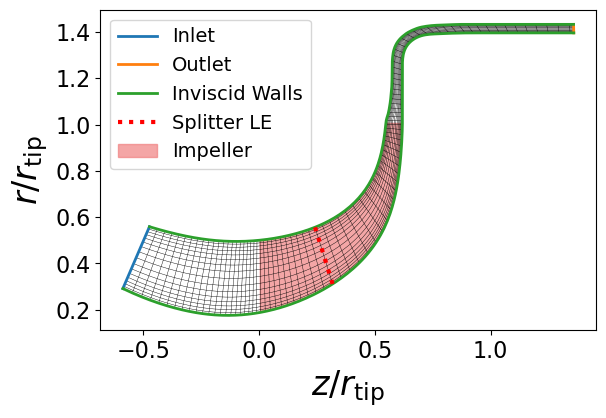

In [21]:
ni,nj = data_dict['ax'].shape

skip = 3
plt.figure()
for i in range(0, ni, skip):
    plt.plot(data_dict['ax'][i,:]/rtip, data_dict['r'][i,:]/rtip, 'k-', linewidth=0.3)
for j in range(0, nj, skip):
    plt.plot(data_dict['ax'][:,j]/rtip, data_dict['r'][:,j]/rtip, 'k-', linewidth=0.3)

plt.plot(data_dict['ax'][0,:]/rtip, data_dict['r'][0,:]/rtip, 'C0-', linewidth=2, label='Inlet')
plt.plot(data_dict['ax'][-1,:]/rtip, data_dict['r'][-1,:]/rtip, 'C1-', linewidth=2, label='Outlet')
plt.plot(data_dict['ax'][:,0]/rtip, data_dict['r'][:,0]/rtip, 'C2-', linewidth=2, label='Inviscid Walls')
plt.plot(data_dict['ax'][:,-1]/rtip, data_dict['r'][:,-1]/rtip, 'C2-', linewidth=2)


# Collect boundary points of the blade passage (in order!)
zgrid, rgrid = data_dict['ax'], data_dict['r']
iLE = 66
iTE = 66+94
z_blade = np.concatenate([
    zgrid[iLE, :],                # LE line (from hub to shroud)
    zgrid[iLE:iTE+1, -1],         # suction side (shroud side, LE -> TE)
    zgrid[iTE, ::-1],             # TE line (from shroud back to hub)
    zgrid[iLE:iTE+1, 0][::-1]     # pressure side (hub side, TE -> LE)
])
r_blade = np.concatenate([
    rgrid[iLE, :],
    rgrid[iLE:iTE+1, -1],
    rgrid[iTE, ::-1],
    rgrid[iLE:iTE+1, 0][::-1]
])
plt.plot(zgrid[iLE+33,:]/rtip, rgrid[iLE+33,:]/rtip, ':r', lw=3, label='Splitter LE')

# Fill polygon
plt.fill(z_blade/rtip, r_blade/rtip, color='lightcoral', alpha=0.7, label='Impeller')




# plt.legend(ncol=2, bbox_to_anchor=(0.5, 1.22), loc='upper center')
plt.legend(fontsize=14, loc='best')
plt.xlabel(r'$z/r_{\rm tip}$')
plt.ylabel(r'$r/r_{\rm tip}$')
# plt.xlim(right=0.4)
# plt.title('(%i x %i)' % (ni, nj))
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig('pictures/hecc_grid.pdf', bbox_inches='tight')

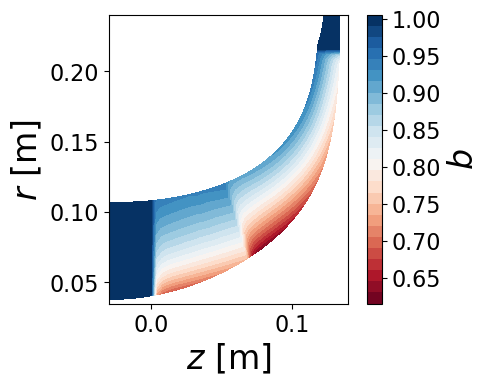

In [8]:
plt.figure(figsize=figsize)
plt.contourf(data_dict['ax'], data_dict['r'], data_dict['blockage'][:,:,0], cmap='RdBu', levels=N_levels, vmax=1)
plt.xlim(right=0.14)
plt.xlim(left=-0.030)
plt.ylim(top=0.24)
plt.ylim(bottom=0.035)
plt.xlabel(r'$z$ [m]')
plt.ylabel(r'$r$ [m]')
cbar = plt.colorbar()
cbar.set_ticks([0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])
cbar.set_label(r'$b$')
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig('hecc_blockage_example.pdf', bbox_inches='tight')